In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")


In [5]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# sklearn target: 0 = malignant, 1 = benign.
# For this notebook, make malignant the positive class.
df["malignant"] = (df["target"] == 0).astype(int)
df = df.drop(columns=["target"])

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
print("Shape:", df.shape)
print("Features:", len(data.feature_names))
print("Target counts:")
print(df["malignant"].value_counts().rename(index={0: "benign", 1: "malignant"}))


Shape: (569, 31)
Features: 30
Target counts:
malignant
benign       357
malignant    212
Name: count, dtype: int64


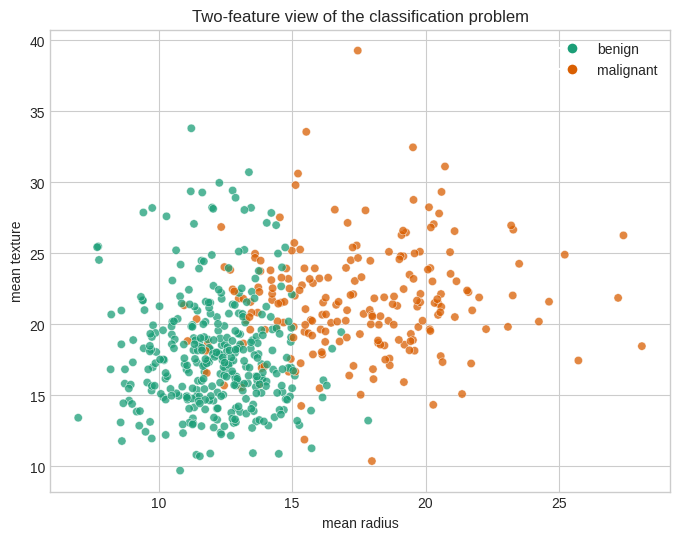

In [6]:
feature_1 = "mean radius"
feature_2 = "mean texture"

fig, ax = plt.subplots(figsize=(8, 6))
colors = np.where(df["malignant"] == 1, "#d95f02", "#1b9e77")
ax.scatter(df[feature_1], df[feature_2], c=colors, alpha=0.75, edgecolor="white", linewidth=0.4)
ax.set_xlabel(feature_1)
ax.set_ylabel(feature_2)
ax.set_title("Two-feature view of the classification problem")

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1b9e77', label='benign', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d95f02', label='malignant', markersize=8),
]
ax.legend(handles=legend_handles)
plt.show()

In [7]:
X_two = df[[feature_1, feature_2]].values
y = df["malignant"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_two, y, test_size=0.25, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])


Training rows: 426
Test rows: 143


In [8]:
from numpy._core.fromnumeric import mean
def fit_standard_scaler(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return mean, std

def transform_standard_scaler(X, mean, std):
    return (X - mean) / std



In [9]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

In [10]:
def predict_prob(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

def compute_gradients(X, y, w, b):
    n = X.shape[0]
    y_pred = predict_prob(X, w, b) # forward pass
    dw = np.dot(X.T, (y_pred - y)) / n # grad calc
    db = np.mean(y_pred - y)
    return dw, db

def update_weights(w, b, dw, db, learning_rate):
    w -= learning_rate * dw
    b -= learning_rate * db
    return w, b

In [11]:
def train_logistic_regression(X, y, learning_rate=0.01, num_iterations=1000):
    n_features = X.shape[1]
    w = np.random.randn(n_features)
    b = np.random.randn()
    losses = []

    for iteration in range(num_iterations):
        dw, db = compute_gradients(X, y, w, b) # forward pass as well
        w, b = update_weights(w, b, dw, db, learning_rate)
        loss = binary_cross_entropy(y, predict_prob(X, w, b))
        losses.append(loss)

    return w, b, losses

In [20]:
w, b, losses = train_logistic_regression(X_train, y_train, learning_rate=0.01, num_iterations=1000)

In [21]:
losses[0], losses[-1]

(np.float64(10.641441759773738), np.float64(0.6072326183143096))

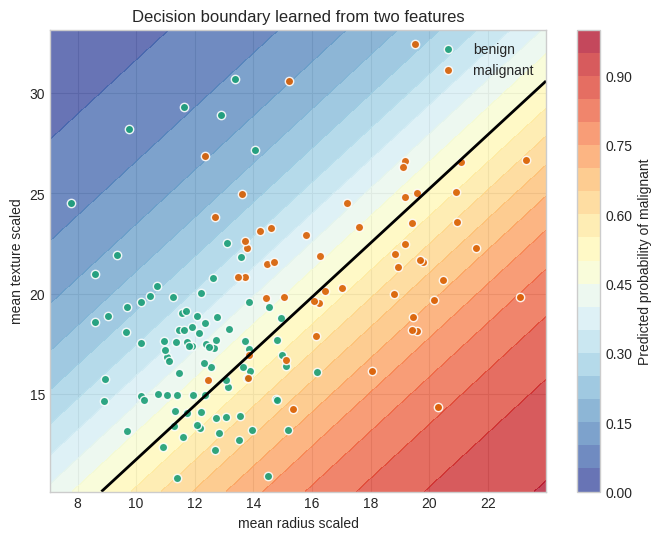

In [22]:
def plot_decision_boundary(X_scaled, y, w, b, title):
    x_min, x_max = X_scaled[:, 0].min() - 0.7, X_scaled[:, 0].max() + 0.7
    y_min, y_max = X_scaled[:, 1].min() - 0.7, X_scaled[:, 1].max() + 0.7
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_prob(grid, w, b).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    bg = ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 21), cmap="RdYlBu_r", alpha=0.75)
    ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], c="#1b9e77", edgecolor="white", label="benign", alpha=0.9)
    ax.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], c="#d95f02", edgecolor="white", label="malignant", alpha=0.9)
    ax.set_xlabel(feature_1 + " scaled")
    ax.set_ylabel(feature_2 + " scaled")
    ax.set_title(title)
    ax.legend()
    fig.colorbar(bg, ax=ax, label="Predicted probability of malignant")
    plt.show()


# plot_decision_boundary(X_train_scaled, y_train, w_two, b_two, "Decision boundary learned from two features")
plot_decision_boundary(X_test, y_test, w, b, "Decision boundary learned from two features")


In [23]:
def predict_class(y_prob, threshold=0.5):
    return (y_prob >= threshold).astype(int)

def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def classification_metrics(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * (precision * recall) / (precision + recall)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "confusion_matrix": np.array([[tp, fp], [fn, tn]])
    }

In [24]:
y_prob_test = predict_prob(X_test, w, b)
y_pred_test = predict_class(y_prob_test)
metrics_test = classification_metrics(y_test, y_pred_test)

In [25]:
metrics_test

{'accuracy': np.float64(0.6363636363636364),
 'precision': np.float64(0.5087719298245614),
 'recall': np.float64(0.5471698113207547),
 'f1_score': np.float64(0.5272727272727273),
 'confusion_matrix': array([[29, 28],
        [24, 62]])}